**Project Description**

This project is about detecting human emotions from speech audio using Python.
The goal is to take an audio file and predict the emotion like happy, sad, angry, or neutral.

It combines signal processing and machine learning to solve a real-world problem.

**Problem This Project Solves**

In real life, speech carries not only words but also emotions.
Understanding emotion from voice is useful in many areas like:

human computer interaction
call center analysis
mental health monitoring

This project shows how we can analyze audio signals and classify emotions automatically.

**What I Did**

Loaded the RAVDESS dataset which contains speech audio with emotion labels.
Downloaded and connected audio files with dataset paths.
Processed audio signals using Python.
Extracted features using MFCC (Mel Frequency Cepstral Coefficients).
Created a dataset of features and labels.
Split data into training and testing sets.
Trained a Random Forest classifier.
Evaluated the model using classification report and confusion matrix.
Visualized audio signals and results.

**Tools and Libraries Used**

Python 3
numpy – numerical operations
librosa – audio processing
matplotlib – plotting and visualization
scikit-learn – machine learning
datasets – loading dataset

**Goal:**

Detect the emotion of a short audio clip (happy, sad, angry, neutral) using signal processing + machine learning.

**What This Project Shows**

Signal processing → MFCC

Machine learning → classification

Real dataset handling

Debugging and fixing paths

Visualization

In [1]:
!pip install librosa numpy pandas matplotlib scikit-learn datasets

In [2]:
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import os

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
dataset = load_dataset("MahiA/RAVDESS")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1961 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/491 [00:00<?, ? examples/s]

In [4]:
!wget -nc https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip
!unzip -oq Audio_Speech_Actors_01-24.zip

--2026-03-31 16:43:26--  https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 188.185.43.153, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 208468073 (199M) [application/octet-stream]
Saving to: ‘Audio_Speech_Actors_01-24.zip’

Audio_Speech_Actors 100%[===================>] 198.81M   749KB/s    in 4m 5s   

2026-03-31 16:47:31 (832 KB/s) - ‘Audio_Speech_Actors_01-24.zip’ saved [208468073/208468073]



In [5]:
for root, dirs, files in os.walk("."):
    if "Actor_" in root:
        print(root)
        print(files[:5])
        break

./Actor_11
['03-01-05-02-02-02-11.wav', '03-01-07-01-01-01-11.wav', '03-01-02-02-02-02-11.wav', '03-01-01-01-01-02-11.wav', '03-01-07-01-01-02-11.wav']


In [6]:
all_files = {}

for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith(".wav"):
            all_files[f] = os.path.join(root, f)

print("Total audio files:", len(all_files))

Total audio files: 1440


In [7]:
def fix_path(example):
    filename = example["path"].split("/")[-1]
    example["real_path"] = all_files.get(filename, None)
    return example

dataset = dataset.map(fix_path)

Map:   0%|          | 0/1961 [00:00<?, ? examples/s]

Map:   0%|          | 0/491 [00:00<?, ? examples/s]

In [8]:
dataset = dataset.filter(lambda x: x["real_path"] is not None)

Filter:   0%|          | 0/1961 [00:00<?, ? examples/s]

Filter:   0%|          | 0/491 [00:00<?, ? examples/s]

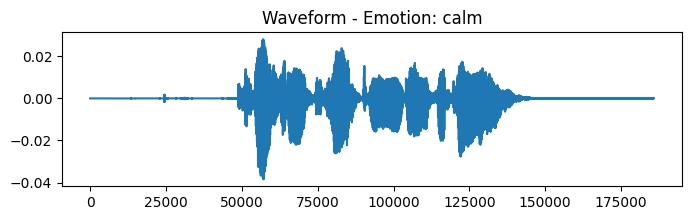

In [9]:
sample = dataset['train'][0]

y, sr = librosa.load(sample["real_path"], sr=None)

plt.figure(figsize=(8,2))
plt.plot(y)
plt.title("Waveform - Emotion: " + sample["classname"])
plt.show()

In [10]:
def extract_features(path):
    y, sr = librosa.load(path, sr=None)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    return np.mean(mfccs.T, axis=0)

In [11]:
X = []
y_labels = []

for item in dataset['train']:
    features = extract_features(item["real_path"])
    X.append(features)
    y_labels.append(item["classname"])

X = np.array(X)
y_labels = np.array(y_labels)

print("Feature shape:", X.shape)

Feature shape: (1146, 13)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42
)

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       angry       0.69      0.76      0.72        29
        calm       0.36      0.72      0.48        25
     disgust       0.53      0.44      0.48        36
     fearful       0.48      0.47      0.47        30
       happy       0.55      0.34      0.42        32
     neutral       0.40      0.33      0.36        18
         sad       0.55      0.41      0.47        27
   surprised       0.53      0.55      0.54        33

    accuracy                           0.50       230
   macro avg       0.51      0.50      0.49       230
weighted avg       0.52      0.50      0.50       230



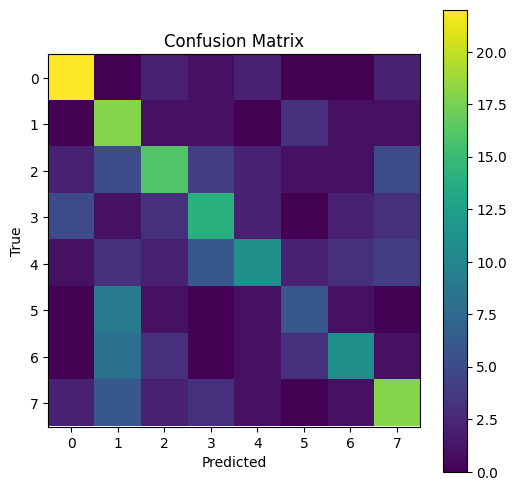

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()